In [2]:
import pandas as pd
from pathlib import Path
import sys
sys.path.append("..")
from src.evaluation import *
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [3]:
data_path = Path("/Users/zhengtaosun/Documents/bootcamp_Zhengtao_Sun/project/data/processed/NVDA_feature_engineering.parquet")
df = pd.read_parquet(data_path)
df["year"] = df["date"].dt.year
df

,date,adj close,close,high,low,open,volume,ticker,daily_rtn,excess_return,outlier_iqr,outlier_winsorize,outlier_z,mom_5,log_return,vol_std_5,next_excess_return,year
0,2020-08-31,13.330562,13.374500,13.575000,13.037750,13.182750,500840000,NVDA,0.017246,0.019441,False,0.019441,False,0.036602,0.040314,0.020906,0.026168,2020
1,2020-09-01,13.779715,13.821000,13.993750,13.436500,13.480000,511316000,NVDA,0.033693,0.026168,False,0.026168,False,0.051434,0.017099,0.019453,0.022656,2020
2,2020-09-02,14.303645,14.346500,14.726750,13.900000,14.703750,874012000,NVDA,0.038022,0.022656,False,0.022656,False,0.084324,0.033138,0.019705,-0.057649,2020
3,2020-09-03,12.976623,13.015500,13.884500,12.878750,13.828750,945128000,NVDA,-0.092775,-0.057649,False,-0.035831,False,0.123525,0.037317,0.021437,-0.022062,2020
4,2020-09-04,12.584794,12.622500,13.175000,11.704750,12.783750,1463684000,NVDA,-0.030195,-0.022062,False,-0.022062,False,0.030974,-0.097365,0.021361,-0.028453,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202,2025-08-11,182.059998,182.059998,183.839996,180.250000,182.050003,138323200,NVDA,-0.003503,-0.000999,False,-0.000999,False,0.051692,0.010620,0.022129,-0.005303,2025
1203,2025-08-12,183.160004,183.160004,184.479996,179.460007,182.960007,145485700,NVDA,0.006042,-0.005303,False,-0.005303,False,0.011444,-0.003509,0.016267,-0.011802,2025
1204,2025-08-13,181.589996,181.589996,183.970001,179.350006,182.619995,179871700,NVDA,-0.008572,-0.011802,False,-0.011802,False,0.027488,0.006024,0.008541,0.002065,2025
1205,2025-08-14,182.020004,182.020004,183.020004,179.460007,179.750000,129554000,NVDA,0.002368,0.002065,False,0.002065,False,0.012095,-0.008609,0.005305,-0.005728,2025


## Baseline Fit & Residuals

In [4]:
# features = ["mom_5","log_return","vol_std_5"]
features = ["vol_std_5"]
X_raw = df[features].values
y = df['next_excess_return'].values
X_base = mean_impute(X_raw)
df['x_imputed'] = X_base
model = LinearRegression().fit(X_base,y)
y_pred = model.predict(X_base)
base_mae = mae(y,y_pred)
base_mae

0.01740457109629519

## Parametric vs Bootstrap CI

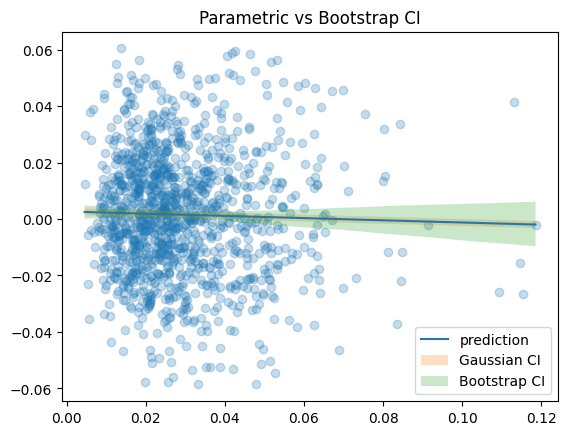

In [5]:
resid = y - y_pred
sigma_hat = np.std(resid, ddof=1)
n = len(y)
se_mean = sigma_hat/np.sqrt(n)
x_grid = np.linspace(np.nanmin(X_base), np.nanmax(X_base), 120).reshape(-1,1)
pred_line = model.predict(x_grid)
gauss_lo = pred_line - 1.96*se_mean
gauss_hi = pred_line + 1.96*se_mean

def bootstrap_predictions(X, y, x_grid, n_boot=500, seed=111):
    rng = np.random.default_rng(seed)
    preds = []
    idx = np.arange(len(y))
    for _ in range(n_boot):
        b = rng.choice(idx, size=len(idx), replace=True)
        m = fit_fn(X[b].reshape(-1,1), y[b])
        preds.append(m.predict(x_grid))
    P = np.vstack(preds)
    return P.mean(axis=0), np.percentile(P, 2.5, axis=0), np.percentile(P, 97.5, axis=0)

m_boot, lo_boot, hi_boot = bootstrap_predictions(X_base, y, x_grid, n_boot=600)

plt.figure()
plt.scatter(X_base, y, alpha=0.25)
plt.plot(x_grid, pred_line, label='prediction')
plt.fill_between(x_grid.ravel(), gauss_lo, gauss_hi, alpha=0.25, label='Gaussian CI')
plt.fill_between(x_grid.ravel(), lo_boot, hi_boot, alpha=0.25, label='Bootstrap CI')
plt.legend(); plt.title('Parametric vs Bootstrap CI'); plt.show()

## Scenarios Sensitivity

In [6]:
scenarios = {
    'mean_impute': mean_impute,
    'median_impute': median_impute,
    'drop_missing': lambda a: a[~np.isnan(a)] if np.isnan(a).any() else a
}

results = []
for name, fn in scenarios.items():
    if name == 'drop_missing' and np.isnan(X_raw).any():
        mask = ~np.isnan(X_raw)
        Xs, ys = X_raw[mask], y[mask]
        m = fit_fn(Xs.reshape(-1,1), ys)
        yh = m.predict(Xs.reshape(-1,1))
    else:
        Xs = fn(X_raw)
        m = fit_fn(Xs.reshape(-1,1), y)
        yh = m.predict(Xs.reshape(-1,1))
    results.append({'scenario': name, 'mae': mae(y[:len(yh)], yh), 'slope': m.coef_[0], 'intercept': m.intercept_})
sens = pd.DataFrame(results); sens

,scenario,mae,slope,intercept
0,mean_impute,0.017405,-0.038993,0.002655
1,median_impute,0.017405,-0.038993,0.002655
2,drop_missing,0.017405,-0.038993,0.002655


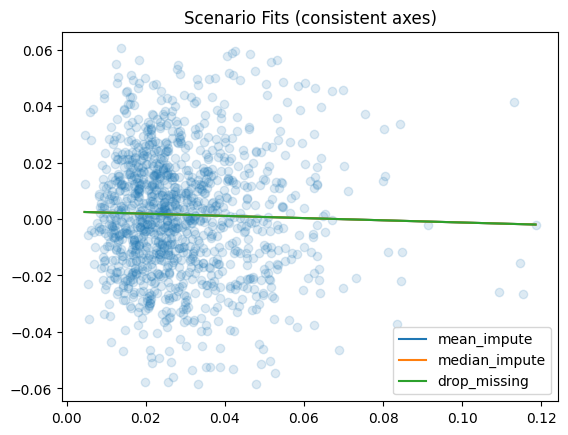

In [7]:
plt.figure()
xg = np.linspace(np.nanmin(X_base), np.nanmax(X_base), 150).reshape(-1,1)
for name, fn in scenarios.items():
    if name == 'drop_missing' and np.isnan(X_raw).any():
        mask = ~np.isnan(X_raw)
        Xi, yi = X_raw[mask], y[mask]
    else:
        Xi, yi = fn(X_raw), y
    m = fit_fn(Xi.reshape(-1,1), yi)
    plt.plot(xg, m.predict(xg), label=name)
plt.scatter(X_base, y, alpha=0.15)
plt.title('Scenario Fits (consistent axes)'); plt.legend(); plt.show()

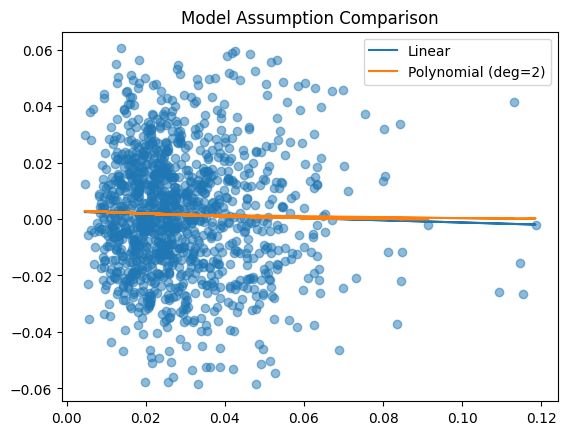

In [8]:
X = df[['vol_std_5']]
y = df['next_excess_return']

lin = LinearRegression().fit(X, y)
poly = make_pipeline(PolynomialFeatures(2), LinearRegression()).fit(X, y)

plt.scatter(X, y, alpha=0.5)
plt.plot(X, lin.predict(X), label='Linear')
plt.plot(X, poly.predict(X), label='Polynomial (deg=2)')
plt.legend()
plt.title('Model Assumption Comparison')
plt.show()



In [9]:
model_base = fit_fn(X_base.reshape(-1,1), y)
df2 = df.copy()
df2['y_hat'] = model_base.predict(df2['x_imputed'].values.reshape(-1,1))
df2['resid'] = df2['next_excess_return'] - df2['y_hat']
g = df2.groupby('year')['resid'].agg(['mean','std','median','count'])
g

,mean,std,median,count
year,,,,
2020,-0.000589,0.019874,-0.002345,84
2021,0.000474,0.021221,-0.001829,245
2022,-0.002794,0.025230,-0.002292,243
2023,0.000288,0.019482,0.001196,244
2024,0.001641,0.022733,0.001125,241
2025,0.000978,0.020068,-0.000319,150


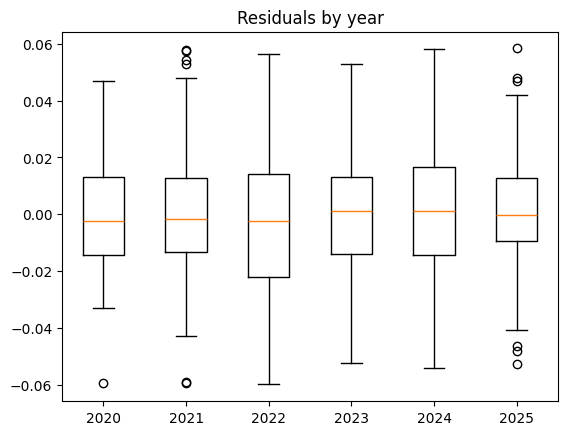

In [10]:
plt.figure()
grouped = df2.groupby('year')['resid']
data = [s.values for _, s in grouped]
labels = list(grouped.groups.keys())

plt.boxplot(data, tick_labels=labels)
plt.title('Residuals by year')
plt.show()

In [11]:
bm = bootstrap_metric(y, df2['y_hat'].values, mae, n_boot=600)
bm

{'mean': 0.017420221744033827,
 'lo': 0.01668006235507099,
 'hi': 0.018201613165805996}